In [88]:
# Import libraries
import requests
import pandas as pd
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import confusion_matrix, classification_report


from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns

In [89]:
# Function to get news data
api_key = "50ef1f5fb7c4422aa3499ac88d54fefd"  # your api access

categories = ["business", "entertainment", "health", "science", "sports", "technology"]

def get_news(api_key, category):

    url = "https://newsapi.org/v2/top-headlines"

    params = {
        'category': category,
        'apiKey': api_key,
        'pageSize': 100  # adjust as needed
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()

    else:
        print(f"Failed to retrieve news for category {category}")
        return None

In [90]:
# Get data for all categories
news_data = []

for category in categories:

    data = get_news(api_key, category)

    if data:

        for article in data.get('articles', []):

            if article['title'] and article['description']:  # Ensure both title and description exist

                article['category'] = category

                news_data.append(article)

df = pd.DataFrame(news_data)

print(df[['title', 'description', 'category']].head())

                                               title  \
0  Stock futures broadly higher as Wall Street aw...   
1  US grocery prices rose in April, but gas spike...   
2  JPMorgan set to reshuffle investment bank chie...   
3  Some Japanese snack packages are turning black...   
4  Elon Musk Had ‘Hair-Raising’ Idea of Passing O...   

                                         description  category  
0  April's producer price index, another key infl...  business  
1  Americans paid more for their groceries in Apr...  business  
2  Dorothee Blessing, Kevin Foley and Jared Kaye ...  business  
3  The packaging on some snacks in Japan is turni...  business  
4  Musk’s lawyers questioned Altman over allegati...  business  


In [91]:
# Text processing
df['text'] = df['title'] + " " + df['description']

texts = df['text'].dropna().tolist()

labels = df['category'].dropna().tolist()

In [92]:
def categorize_text(text):

    text = str(text).lower()

    for keyword in analytic_keywords:
        if keyword in text:
            return 'Analitik'

    return 'Naratif'

df['category'] = df['text'].apply(categorize_text)

In [93]:
# Ensure texts and labels are the same length
assert len(texts) == len(labels), "Texts and labels are not of the same length!"

In [94]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Kumpulan stopwords semua bahasa
all_stopwords = set()

for lang in stopwords.fileids():
    all_stopwords.update(stopwords.words(lang))

# Fungsi normalisasi
def normalize_text(text):

    if not isinstance(text, str):
        return ""

    tokens = word_tokenize(text)

    tokens = [word.lower() for word in tokens if word.isalpha()]

    tokens = [word for word in tokens if word not in all_stopwords]

    return ' '.join(tokens)

# Contoh data

# Terapkan normalisasi
normalized_texts = [normalize_text(text) for text in texts]

print(normalized_texts)

['stock futures broadly higher wall street awaits april inflation report live updates cnbc april producer price index key inflation report released wednesday morning', 'grocery prices rose april gas spikes reason news americans paid groceries april high gas prices reasons government figures released tuesday showed prices food eaten home rose month compared year earlier highest', 'jpmorgan set reshuffle investment bank chiefs amid wider financial times dorothee blessing kevin foley jared kaye expected global investment banking', 'japanese snack packages turning iran depletes ink supply yahoo packaging snacks japan turning somber iran disrupts supply ingredient colored ink', 'elon musk idea passing openai kids sam altman wired musk lawyers questioned altman allegations deception network financial investments openai ceo painted picture musk obsessed controlling company', 'chevron ceo physical oil shortages starting means cvx stock motley fool global economy burning oil refined products st

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pongo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pongo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pongo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [95]:
# TF-IDF
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(normalized_texts)

# Label kategori
y = df['category']

print(X.shape)
print(y.shape)

(222, 2601)
(222,)


In [96]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [97]:
# Train model
model = MultinomialNB()

# Training model
model.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [98]:

# Prediksi data testing

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detail evaluasi
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

    Analitik       0.00      0.00      0.00         1
     Naratif       0.99      1.00      0.99        66

    accuracy                           0.99        67
   macro avg       0.49      0.50      0.50        67
weighted avg       0.97      0.99      0.98        67



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [99]:
# Predict
y_pred = model.predict(X_test)

In [100]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[ 0  1]
 [ 0 66]]


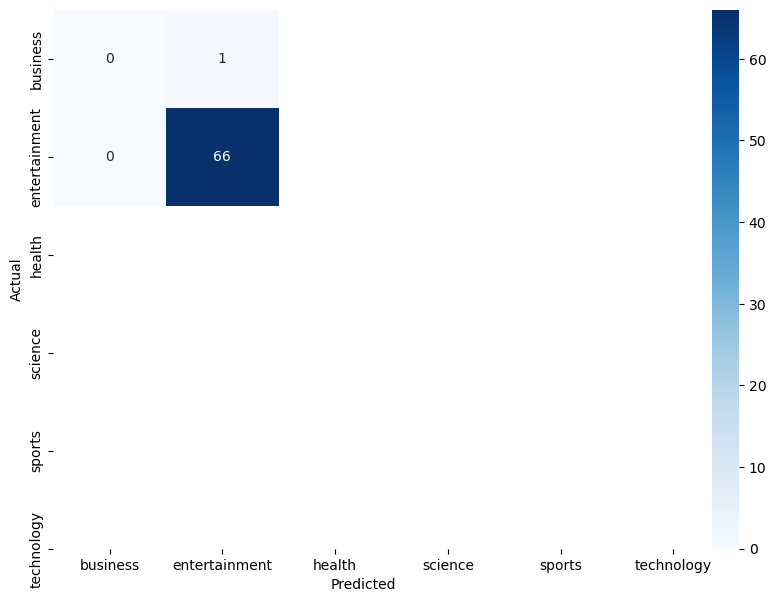

In [101]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 7))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories
)

plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [102]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Analitik       0.00      0.00      0.00         1
     Naratif       0.99      1.00      0.99        66

    accuracy                           0.99        67
   macro avg       0.49      0.50      0.50        67
weighted avg       0.97      0.99      0.98        67



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


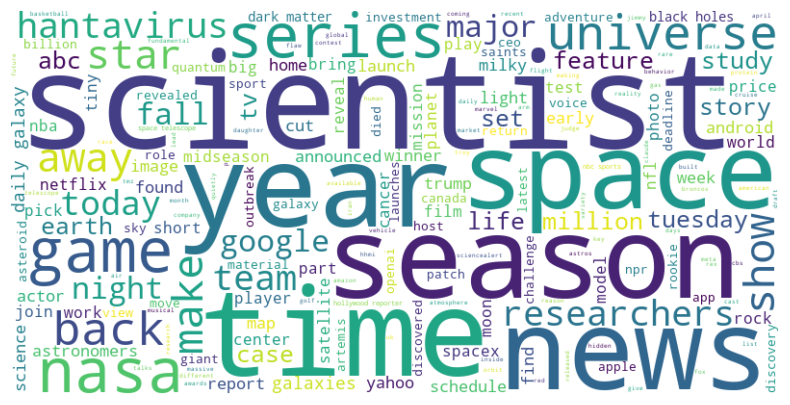

In [103]:
# WordCloud
all_text = ' '.join(normalized_texts)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.show()

In [104]:
# Uji prediksi berita baru
berita_baru = [
    "Menurut pengamat ekonomi, kebijakan pemerintah dapat meningkatkan investasi asing di Indonesia.",

    "Kecelakaan lalu lintas terjadi pada pagi hari dan menyebabkan kemacetan panjang.",

    "Analis politik menilai keputusan tersebut akan mempengaruhi elektabilitas partai.",

    "Tim SAR berhasil menemukan korban setelah pencarian selama tiga hari.",

    "Pakar pendidikan berpendapat bahwa kurikulum baru mampu meningkatkan kualitas belajar siswa."
]

# Normalisasi text berita baru
normalized_news = [normalize_text(text) for text in berita_baru]

# Transform ke TF-IDF
news_vector = vectorizer.transform(normalized_news)

# Prediksi kategori berita
predictions = model.predict(news_vector)

# Menampilkan hasil prediksi
for i, (berita, kategori) in enumerate(zip(berita_baru, predictions), start=1):
#for i, (text, pred) in enumerate(zip(new_texts, predictions), start=1):
    print(f"Berita {i}")
    print("Berita   :", berita)

    print("Prediksi :", kategori)
    print("-" * 60)
    print()


Berita 1
Berita   : Menurut pengamat ekonomi, kebijakan pemerintah dapat meningkatkan investasi asing di Indonesia.
Prediksi : Naratif
------------------------------------------------------------

Berita 2
Berita   : Kecelakaan lalu lintas terjadi pada pagi hari dan menyebabkan kemacetan panjang.
Prediksi : Naratif
------------------------------------------------------------

Berita 3
Berita   : Analis politik menilai keputusan tersebut akan mempengaruhi elektabilitas partai.
Prediksi : Naratif
------------------------------------------------------------

Berita 4
Berita   : Tim SAR berhasil menemukan korban setelah pencarian selama tiga hari.
Prediksi : Naratif
------------------------------------------------------------

Berita 5
Berita   : Pakar pendidikan berpendapat bahwa kurikulum baru mampu meningkatkan kualitas belajar siswa.
Prediksi : Naratif
------------------------------------------------------------



In [105]:
from collections import Counter

# Menghitung kategori yang muncul
count = Counter(predictions)

print("Jumlah kategori hasil prediksi:")
print(count)

# Kategori paling sering muncul
most_common = count.most_common(1)[0]

print("\nKategori yang paling sering muncul:")
print(most_common[0], "-", most_common[1], "kali")

Jumlah kategori hasil prediksi:
Counter({np.str_('Naratif'): 5})

Kategori yang paling sering muncul:
Naratif - 5 kali
